Original Dataset:
  User_ID  Basket_Size  Total_Spent Loyalty_Tier
0      U1           12          140         Gold
1      U2            2           15       Silver
2      U3           15          180         Gold
3      U4            3           22       Bronze
4      U5            8           95       Silver

Normalized Data:
[[0.76923077 0.75757576]
 [0.         0.        ]
 [1.         1.        ]
 [0.07692308 0.04242424]
 [0.46153846 0.48484848]]

Cluster Results:
  User_ID  Basket_Size  Total_Spent Loyalty_Tier  Cluster
0      U1           12          140         Gold        0
1      U2            2           15       Silver        1
2      U3           15          180         Gold        0
3      U4            3           22       Bronze        1
4      U5            8           95       Silver        0


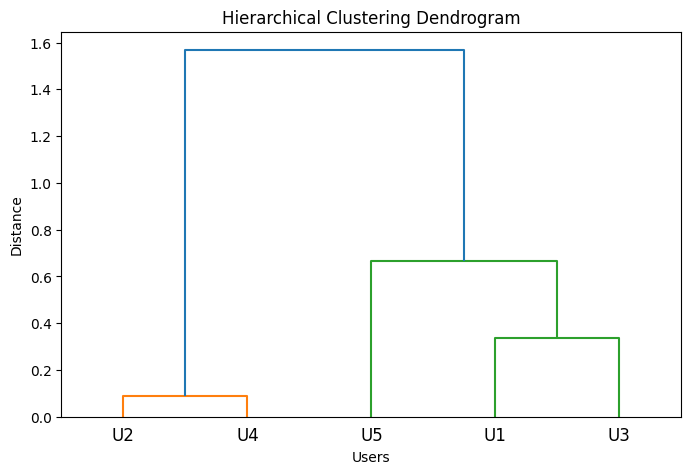


Clusters at Threshold 0.5:
  User_ID  Basket_Size  Total_Spent Loyalty_Tier  Cluster  Threshold_Cluster
0      U1           12          140         Gold        0                  2
1      U2            2           15       Silver        1                  1
2      U3           15          180         Gold        0                  2
3      U4            3           22       Bronze        1                  1
4      U5            8           95       Silver        0                  3


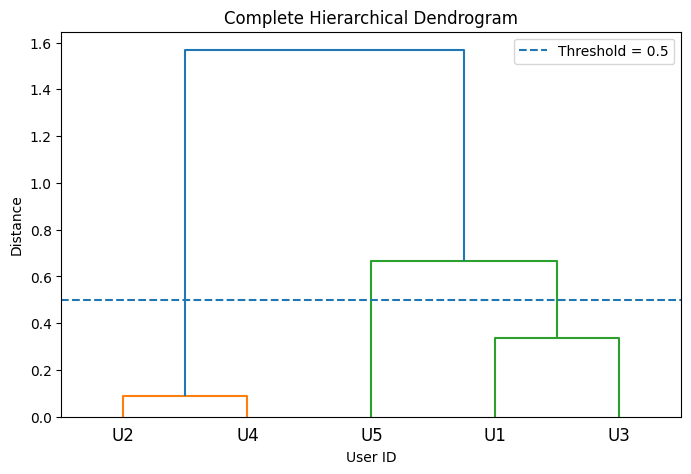

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Create dataset
data = {
    'User_ID': ['U1', 'U2', 'U3', 'U4', 'U5'],
    'Basket_Size': [12, 2, 15, 3, 8],
    'Total_Spent': [140, 15, 180, 22, 95],
    'Loyalty_Tier': ['Gold', 'Silver', 'Gold', 'Bronze', 'Silver']
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)


# 1. Min-Max Normalization

X = df[['Basket_Size', 'Total_Spent']]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("\nNormalized Data:")
print(X_scaled)


# 2. Hierarchical Agglomerative Clustering

model = AgglomerativeClustering(n_clusters=2)

df['Cluster'] = model.fit_predict(X_scaled)

print("\nCluster Results:")
print(df)


# 3. Create Dendrogram

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(8, 5))

dendrogram(
    Z,
    labels=df['User_ID'].values
)

plt.xlabel("Users")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()


# 4. Clusters at threshold distance 0.5

threshold_clusters = fcluster(
    Z,
    t=0.5,
    criterion='distance'
)

df['Threshold_Cluster'] = threshold_clusters

print("\nClusters at Threshold 0.5:")
print(df)


# 5. Complete Dendrogram with Threshold Line

plt.figure(figsize=(8, 5))

dendrogram(
    Z,
    labels=df['User_ID'].values
)

plt.axhline(
    y=0.5,
    linestyle='--',
    label='Threshold = 0.5'
)

plt.xlabel("User ID")
plt.ylabel("Distance")
plt.title("Complete Hierarchical Dendrogram")

plt.legend()
plt.show()